In [1]:
import pandas as pd

In [7]:
df = pd.read_csv("house_prices.csv")

In [8]:
df.shape

(187531, 21)

In [9]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [10]:
df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [12]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [13]:
df.isna().mean().sort_values(ascending=False)

,0
Plot Area,1.000000
Dimensions,1.000000
Society,0.584853
Super Area,0.574225
Car Parking,0.551146
overlooking,0.434254
Carpet Area,0.430185
facing,0.374514
Ownership,0.349366
Balcony,0.260944


## 2.1 Load & Inspect

The dataset contains 187,531 rows and 21 columns.

Numeric columns:
- Index
- Price (in rupees)
- Dimensions
- Plot Area

Most of the remaining columns are stored as text/object columns.

The columns with the most missing values are:
- Plot Area: 100%
- Dimensions: 100%
- Society: about 58.5%
- Super Area: about 57.4%
- Car Parking: about 55.1%
- Carpet Area: about 43.0%


In [14]:
def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7

        return float(x.replace(",", ""))

    except ValueError:
        return None


df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

In [17]:
df[["Amount(in rupees)", "price_clean"]].head(10)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [16]:
df = df.dropna(subset=["price_clean"])

In [18]:
df.shape

(177847, 22)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

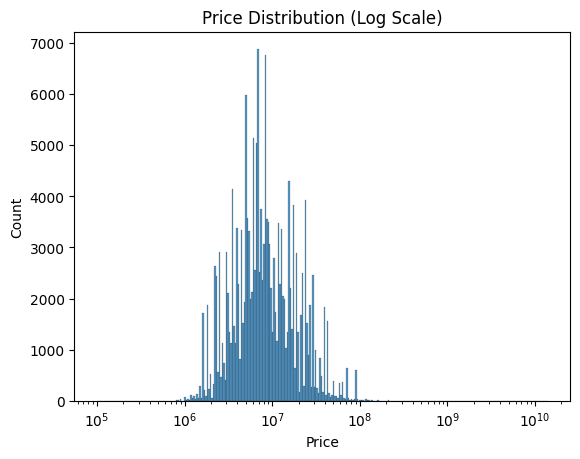

In [20]:
sns.histplot(df["price_clean"], log_scale=True)

plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

### Price Distribution

The price distribution is highly skewed, with most properties concentrated in the lower and middle price ranges and a smaller number of very expensive properties. A logarithmic scale was used to make the distribution easier to visualize.

In [21]:
df["Carpet Area"].dropna().head(20)

,Carpet Area
0,500 sqft
1,473 sqft
2,779 sqft
3,530 sqft
4,635 sqft
6,550 sqft
9,900 sqft
10,950 sqft
13,1820 sqft
15,675 sqft


In [22]:
df["Carpet Area"].dropna().str.extract(r'([a-zA-Z]+)$')[0].value_counts()

,count
0,
sqft,95986
sqyrd,4658
sqm,870
acre,2
kanal,2
marla,2
bigha,1
ground,1


In [23]:
import numpy as np
import re

def parse_area(x):
    if not isinstance(x, str):
        return np.nan

    x = x.strip().lower()

    match = re.search(r'([\d.]+)\s*([a-zA-Z]+)', x)

    if not match:
        return np.nan

    value = float(match.group(1))
    unit = match.group(2)

    if unit == "sqft":
        return value

    elif unit == "sqyrd":
        return value * 9

    elif unit == "sqm":
        return value * 10.764

    elif unit == "acre":
        return value * 43560

    else:
        return np.nan


df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)


In [24]:
df[["Carpet Area", "carpet_area_sqft"]].dropna().head(20)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
6,550 sqft,550.0
9,900 sqft,900.0
10,950 sqft,950.0
13,1820 sqft,1820.0
15,675 sqft,675.0


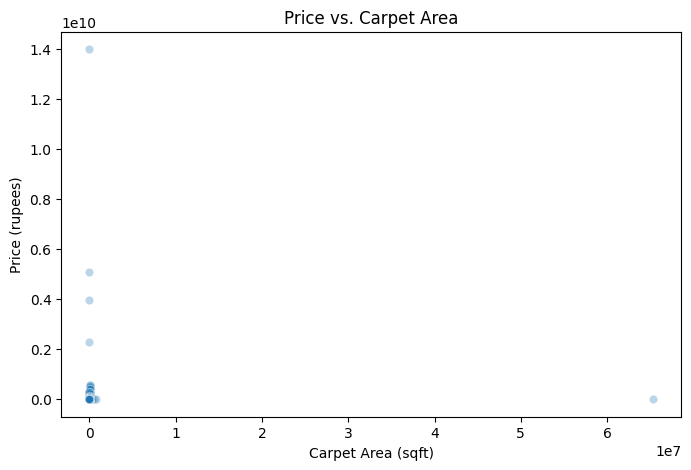

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.3
)

plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (rupees)")

plt.show()

### Price vs. Carpet Area

The scatter plot shows the relationship between carpet area and property price. Most properties are concentrated in the lower area and price ranges, while a few extreme outliers have very large areas or prices. These outliers will be handled later during the data cleaning stage.

In [26]:
df["location"].value_counts().head(15)

,count
location,
new-delhi,24945
bangalore,23262
kolkata,21605
gurgaon,18846
ahmedabad,12614
hyderabad,11147
chennai,10163
jaipur,7867
greater-noida,4490


In [27]:
top_15_locations = df["location"].value_counts().head(15).index

avg_price_by_location = (
    df[df["location"].isin(top_15_locations)]
    .groupby("location")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_by_location

,price_clean
location,
mumbai,3.355292e+07
gurgaon,2.170470e+07
new-delhi,1.616784e+07
hyderabad,1.526815e+07
chennai,1.139704e+07
vadodara,1.082852e+07
pune,1.052901e+07
ahmedabad,1.027555e+07
bangalore,1.006305e+07


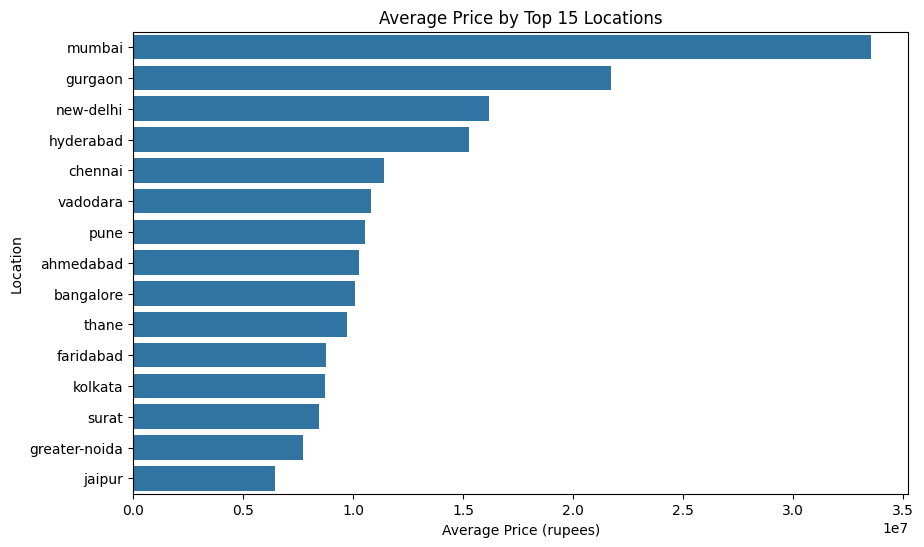

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_by_location.values,
    y=avg_price_by_location.index
)

plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price (rupees)")
plt.ylabel("Location")

plt.show()

### Average Price by Top 15 Locations

The average property price varies significantly across locations. Mumbai has the highest average price among the top 15 locations, followed by Gurgaon and New Delhi. Jaipur has the lowest average price in this group. This indicates that location is likely to be an important feature for predicting house prices.

In [29]:
df["Furnishing"].value_counts(dropna=False)

,count
Furnishing,
Semi-Furnished,82868
Unfurnished,73491
Furnished,19421
NaN,2067


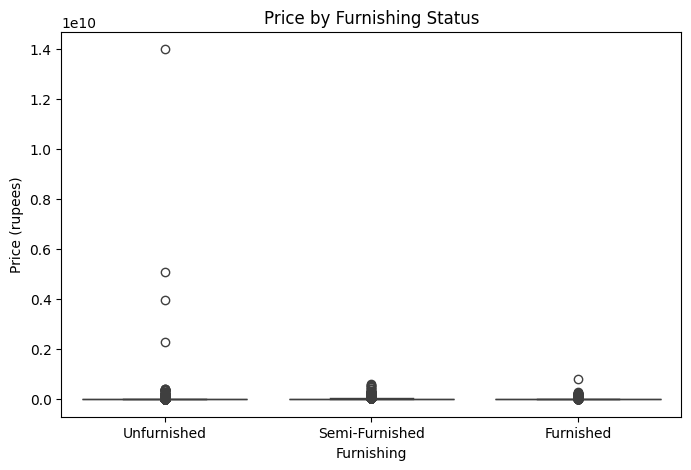

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (rupees)")

plt.show()


### Price by Furnishing Status

The box plot shows that property prices vary across furnishing categories. However, there are several extreme outliers, especially in the Unfurnished category, which make the main distribution appear compressed. These outliers will be handled during the data cleaning stage.

In [31]:
df["Floor"].dropna().head(30)

,Floor
0,10 out of 11
1,3 out of 22
2,10 out of 29
3,1 out of 3
4,20 out of 42
5,2 out of 7
6,4 out of 5
7,Ground out of 7
8,Ground out of 2
9,3 out of 27


In [32]:
def parse_floor(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    if x.startswith("ground"):
        return 0

    if x.startswith("basement"):
        return -1

    try:
        return int(x.split("out of")[0].strip())
    except:
        return None


df["floor_num"] = df["Floor"].apply(parse_floor)

In [33]:
df[["Floor", "floor_num"]].head(20)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [34]:
df["Bathroom"].value_counts(dropna=False).head(20)

,count
Bathroom,
2,88999
3,54187
1,15509
4,14826
5,3281
NaN,760
6,187
7,32
> 10,29


In [35]:
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

In [36]:
df[["Bathroom", "bathroom"]].value_counts(dropna=False).head(15)

,,count
Bathroom,bathroom,
2,2.0,88999
3,3.0,54187
1,1.0,15509
4,4.0,14826
5,5.0,3281
NaN,NaN,760
6,6.0,187
7,7.0,32
> 10,NaN,29


In [37]:
df["bathroom"].median()

2.0

In [38]:
df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())

In [39]:
df["bathroom"].isna().sum()

np.int64(0)

In [40]:
df["Balcony"].value_counts(dropna=False).head(20)

,count
Balcony,
2,50311
NaN,47159
1,45145
3,24958
4,9275
5,814
6,127
> 10,16
7,14


In [41]:
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

In [42]:
df["balcony"].median()

2.0

In [43]:
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

In [44]:
df["balcony"].isna().sum()

np.int64(0)

In [45]:
df["Car Parking"].value_counts(dropna=False).head(20)

,count
Car Parking,
NaN,95912
1 Covered,37760
"1 Covered,",16893
2 Covered,10020
1 Open,7697
"2 Covered,",3968
2 Open,2560
10 Open,843
34 Covered,573


In [46]:
df["car_parking"] = (
    df["Car Parking"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

df["car_parking"] = pd.to_numeric(df["car_parking"], errors="coerce")

In [47]:
df["car_parking"].value_counts(dropna=False).sort_index().head(30)

,count
car_parking,
1.0,62350
2.0,16548
3.0,564
4.0,162
5.0,65
6.0,39
7.0,14
8.0,31
9.0,9


In [48]:
df["car_parking"].median()

1.0

In [49]:
df["car_parking"] = df["car_parking"].fillna(df["car_parking"].median())

In [50]:
df["car_parking"].isna().sum()

np.int64(0)

In [51]:
df["location"].nunique()

81

In [52]:
top_50_locations = df["location"].value_counts().head(50).index

df["location_grouped"] = df["location"].apply(
    lambda x: x if x in top_50_locations else "other"
)

In [53]:
df["location_grouped"].value_counts().head(60)

,count
location_grouped,
new-delhi,24945
bangalore,23262
kolkata,21605
gurgaon,18846
ahmedabad,12614
hyderabad,11147
chennai,10163
jaipur,7867
greater-noida,4490


In [54]:
df["location_grouped"].nunique()

51

In [55]:
df = df.drop(
    columns=[
        "Index",
        "Title",
        "Description",
        "Dimensions",
        "Plot Area"
    ],
    errors="ignore"
)

In [56]:
df.columns.tolist()

['Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'bathroom',
 'balcony',
 'car_parking',
 'location_grouped']

In [57]:
df["price_per_sqft"] = np.where(
    df["carpet_area_sqft"] > 0,
    df["price_clean"] / df["carpet_area_sqft"],
    np.nan
)

In [58]:
df["price_per_sqft"].describe()

,price_per_sqft
count,1.015160e+05
mean,1.019695e+04
std,5.109373e+04
min,8.417508e-02
25%,5.247718e+03
50%,7.800000e+03
75%,1.236087e+04
max,1.118450e+07


In [59]:
lower_limit = df["price_per_sqft"].quantile(0.01)
upper_limit = df["price_per_sqft"].quantile(0.99)

print("1st percentile:", lower_limit)
print("99th percentile:", upper_limit)

1st percentile: 2700.0
99th percentile: 36000.0


In [60]:
before_rows = len(df)

df = df[
    df["price_per_sqft"].isna() |
    df["price_per_sqft"].between(lower_limit, upper_limit)
].copy()

after_rows = len(df)

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before: 177847
Rows after: 176203
Rows removed: 1644


In [61]:
features_to_check = [
    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "balcony",
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

df[features_to_check].isna().sum()

,0
carpet_area_sqft,76331
floor_num,7218
bathroom,0
balcony,0
location_grouped,0
Furnishing,2066
Transaction,64
Ownership,61573
facing,65315


In [62]:
numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "balcony"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

In [63]:
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['carpet_area_sqft', 'floor_num', 'bathroom', 'balcony']
Categorical features: ['location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),
        numeric_features
    ),
    (
        "cat",
        Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

In [65]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['carpet_area_sqft', 'floor_num', 'bathroom',
                                  'balcony']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['location_grouped', 'Furnishing',
                                  'Transaction', 'Ownership', 'facing'])])

In [66]:
X = df[numeric_features + categorical_features]
y = df["price_clean"]

In [67]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (176203, 9)
y shape: (176203,)


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (140962, 9)
X_test : (35241, 9)
y_train: (140962,)
y_test : (35241,)


In [70]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

In [71]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('reg', LinearRegression())])

In [72]:
linear_model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('reg', LinearRegression())])

In [73]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = root_mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MAE :", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²  :", linear_r2)

Linear Regression MAE : 4496984.066294326
Linear Regression RMSE: 10119954.754286777
Linear Regression R²  : 0.49087098004456986


In [76]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ))
])

In [77]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('reg',
                 RandomForestRegressor(n_estimators=50, n_jobs=-1,
                                       random_state=42))])

In [78]:
rf_pred = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²  :", rf_r2)

Random Forest MAE : 1369097.8524681884
Random Forest RMSE: 7934690.391964954
Random Forest R²  : 0.6870098419005017


In [79]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,4.496984e+06,1.011995e+07,0.490871
1,Random Forest,1.369098e+06,7.934690e+06,0.687010


### Model Comparison

The Random Forest model performed better than Linear Regression. It achieved a lower MAE and RMSE and a higher R² score. Therefore, Random Forest was selected as the final model for the house price prediction system.

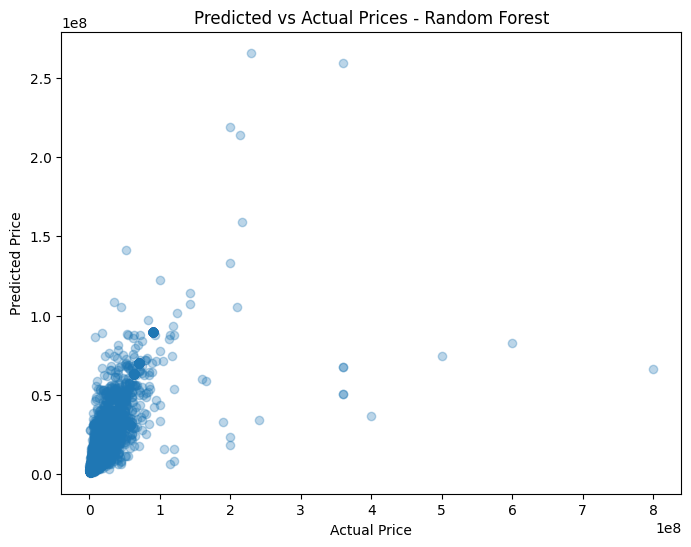

In [80]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices - Random Forest")

plt.show()

### Predicted vs Actual Prices

The scatter plot shows that many predicted prices are reasonably close to the actual prices. However, some large prediction errors are still present, especially for very expensive properties. Overall, the Random Forest model provides a better fit than the Linear Regression baseline.

In [81]:
import joblib

joblib.dump(random_forest_model, "house_price.pkl")

['house_price.pkl']

In [82]:
loaded_model = joblib.load("house_price.pkl")

sample = X_test.iloc[[0]]

print("Reloaded prediction:", loaded_model.predict(sample))

Reloaded prediction: [4205200.]


In [83]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w")
)

In [84]:
import os
os.listdir()

['.config',
 'house_prices.csv',
 'locations.json',
 'house_price.pkl',
 'sample_data']

In [85]:
import sklearn
print(sklearn.__version__)

1.6.1
